In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(f"Folder: {dirname}")
    print(f"Number of files: {len(filenames)}")

    # First 5 files
    for file in filenames[:5]:
        print(file)

    print("-" * 50)

Folder: /kaggle/input
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/datasets
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal/roco-dataset
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal/roco-dataset/all_data
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal/roco-dataset/all_data/validation
Number of files: 1
radiologyvaldata.csv
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal/roco-dataset/all_data/validation/radiology
Number of files: 7
captions.txt
cuis.txt
keywords.txt
licences.txt
valdata.csv
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal/roco-dataset/

In [2]:
import pandas as pd

train_csv = "/kaggle/input/datasets/virajbagal/roco-dataset/all_data/train/radiologytraindata.csv"

df = pd.read_csv(train_csv)

print(df.head())
print("\nColumns:")
print(df.columns)
print("\nShape:")
print(df.shape)

           id                                    name  \
0  ROCO_00002          PMC4083729_AMHSR-4-14-g002.jpg   
1  ROCO_00003       PMC2837471_IJD2009-150251.001.jpg   
2  ROCO_00004  PMC2505281_11999_2007_30_Fig6_HTML.jpg   
3  ROCO_00005       PMC3745845_IJD2013-683423.005.jpg   
4  ROCO_00007   PMC4917066_amjcaserep-17-301-g001.jpg   

                                             caption  
0   Computed tomography scan in axial view showin...  
1   Bacterial contamination occurred after comple...  
2   The patient had residual paralysis of the han...  
3    Panoramic radiograph after immediate loading.\n  
4   Plain abdomen x-ray: Multiple air levels at t...  

Columns:
Index(['id', 'name', 'caption'], dtype='object')

Shape:
(65450, 3)


In [3]:
from PIL import Image
from tqdm import tqdm
import os
import pandas as pd

folders_to_check = [
    "/kaggle/input/datasets/virajbagal/roco-dataset/all_data/train/radiology/images",
    "/kaggle/input/datasets/virajbagal/roco-dataset/all_data/train/non-radiology/images",
    "/kaggle/input/datasets/virajbagal/roco-dataset/all_data/validation/radiology/images",
    "/kaggle/input/datasets/virajbagal/roco-dataset/all_data/validation/non-radiology/images",
    "/kaggle/input/datasets/virajbagal/roco-dataset/all_data/test/radiology/images",
    "/kaggle/input/datasets/virajbagal/roco-dataset/all_data/test/non-radiology/images"
]

results = []

for folder in folders_to_check:

    print(f"\nChecking: {folder}")

    files = os.listdir(folder)

    for file in tqdm(files):

        path = os.path.join(folder, file)

        status = "Valid"

        try:
            # Check file size
            if os.path.getsize(path) == 0:
                status = "Zero-byte"

            else:
                # Verify image integrity
                with Image.open(path) as img:
                    img.verify()

        except Exception as e:
            status = f"Corrupted ({type(e).__name__})"

        if status != "Valid":
            results.append({
                "folder": folder,
                "file": file,
                "status": status
            })

print("\n" + "="*60)
print("SUMMARY")
print("="*60)

if len(results) == 0:
    print("No corrupted images found. All images are valid.")
else:
    print(f"Total problematic images: {len(results)}")

    invalid_df = pd.DataFrame(results)

    print("\nIssue counts:")
    print(invalid_df["status"].value_counts())

    print("\nFirst 20 problematic files:")
    print(invalid_df.head(20))

    invalid_df.to_csv("invalid_images_report.csv", index=False)

    print("\nReport saved as: invalid_images_report.csv")


Checking: /kaggle/input/datasets/virajbagal/roco-dataset/all_data/train/radiology/images


100%|██████████| 65420/65420 [13:14<00:00, 82.38it/s] 



Checking: /kaggle/input/datasets/virajbagal/roco-dataset/all_data/train/non-radiology/images


100%|██████████| 4887/4887 [01:05<00:00, 74.60it/s]



Checking: /kaggle/input/datasets/virajbagal/roco-dataset/all_data/validation/radiology/images


...


Checking: /kaggle/input/datasets/virajbagal/roco-dataset/all_data/test/radiology/images


100%|██████████| 8176/8176 [02:17<00:00, 59.60it/s]



Checking: /kaggle/input/datasets/virajbagal/roco-dataset/all_data/test/non-radiology/images


100%|██████████| 610/610 [00:09<00:00, 65.57it/s]


SUMMARY
Total problematic images: 1

Issue counts:
status
Zero-byte    1
Name: count, dtype: int64

First 20 problematic files:
                                              folder  \
0  /kaggle/input/datasets/virajbagal/roco-dataset...   

                            file     status  
0  PMC4240561_MA-68-291-g002.jpg  Zero-byte  

Report saved as: invalid_images_report.csv


In [4]:
# ==========================================
# REMOVE INVALID IMAGES
# ==========================================

import pandas as pd

# Load invalid image report
invalid_df = pd.read_csv("invalid_images_report.csv")

# Get invalid image names
invalid_images = set(invalid_df["file"])

print(f"Total invalid images found: {len(invalid_images)}")
print(invalid_images)

Total invalid images found: 1
{'PMC4240561_MA-68-291-g002.jpg'}


In [6]:
# ==========================
# IMPORT LIBRARIES
# ==========================

import os
import re
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

print("PyTorch Version:", torch.__version__)
print("TorchVision Version:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

PyTorch Version: 2.10.0+cpu
TorchVision Version: 0.25.0+cpu
Device: cpu


In [7]:
BASE_PATH = "/kaggle/input/datasets/virajbagal/roco-dataset/all_data"

TRAIN_CSV = f"{BASE_PATH}/train/radiologytraindata.csv"
VAL_CSV   = f"{BASE_PATH}/validation/radiologyvaldata.csv"
TEST_CSV  = f"{BASE_PATH}/test/radiologytestdata.csv"

TRAIN_IMG_DIR = f"{BASE_PATH}/train/radiology/images"
VAL_IMG_DIR   = f"{BASE_PATH}/validation/radiology/images"
TEST_IMG_DIR  = f"{BASE_PATH}/test/radiology/images"

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

In [8]:
train_df["image_path"] = train_df["name"].apply(
    lambda x: os.path.join(TRAIN_IMG_DIR, x)
)

val_df["image_path"] = val_df["name"].apply(
    lambda x: os.path.join(VAL_IMG_DIR, x)
)

test_df["image_path"] = test_df["name"].apply(
    lambda x: os.path.join(TEST_IMG_DIR, x)
)

In [9]:
# Remove invalid images from all dataframes

train_before = len(train_df)
val_before = len(val_df)
test_before = len(test_df)

train_df = train_df[
    ~train_df["name"].isin(invalid_images)
].reset_index(drop=True)

val_df = val_df[
    ~val_df["name"].isin(invalid_images)
].reset_index(drop=True)

test_df = test_df[
    ~test_df["name"].isin(invalid_images)
].reset_index(drop=True)

print(f"Train: {train_before} --> {len(train_df)}")
print(f"Validation: {val_before} --> {len(val_df)}")
print(f"Test: {test_before} --> {len(test_df)}")

Train: 65450 --> 65449
Validation: 8180 --> 8180
Test: 8179 --> 8179


In [10]:
train_df[train_df["name"] == "PMC4240561_MA-68-291-g002.jpg"]

,id,name,caption,image_path


In [11]:
# ==========================================
# DATASET INTEGRITY CHECK
# ==========================================

def check_images(df):
    
    missing = 0
    
    for path in df["image_path"]:
        if not os.path.exists(path):
            missing += 1
            
    return missing

train_missing = check_images(train_df)
val_missing = check_images(val_df)
test_missing = check_images(test_df)

print("="*50)
print("TRAIN Missing Images :", train_missing)
print("VALIDATION Missing Images :", val_missing)
print("TEST Missing Images :", test_missing)
print("="*50)

total_images = len(train_df) + len(val_df) + len(test_df)

print("\nTotal Samples:", total_images)

TRAIN Missing Images : 30
VALIDATION Missing Images : 5
TEST Missing Images : 3

Total Samples: 81808


In [12]:
# ==========================================
# REMOVE MISSING IMAGE RECORDS
# ==========================================

train_df = train_df[
    train_df["image_path"].apply(os.path.exists)
].reset_index(drop=True)

val_df = val_df[
    val_df["image_path"].apply(os.path.exists)
].reset_index(drop=True)

test_df = test_df[
    test_df["image_path"].apply(os.path.exists)
].reset_index(drop=True)

print("Train Shape :", train_df.shape)
print("Val Shape   :", val_df.shape)
print("Test Shape  :", test_df.shape)

Train Shape : (65419, 4)
Val Shape   : (8175, 4)
Test Shape  : (8176, 4)


Train: 65419
Validation: 8175
Test: 8176


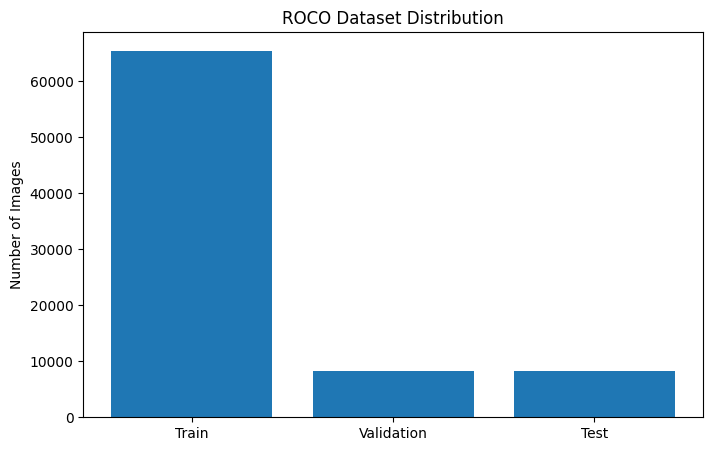

In [13]:
# ==========================================
# DATASET DISTRIBUTION
# ==========================================

train_count = len(train_df)
val_count = len(val_df)
test_count = len(test_df)

print("Train:", train_count)
print("Validation:", val_count)
print("Test:", test_count)

plt.figure(figsize=(8,5))

plt.bar(
    ["Train","Validation","Test"],
    [train_count,val_count,test_count]
)

plt.title("ROCO Dataset Distribution")
plt.ylabel("Number of Images")

plt.show()

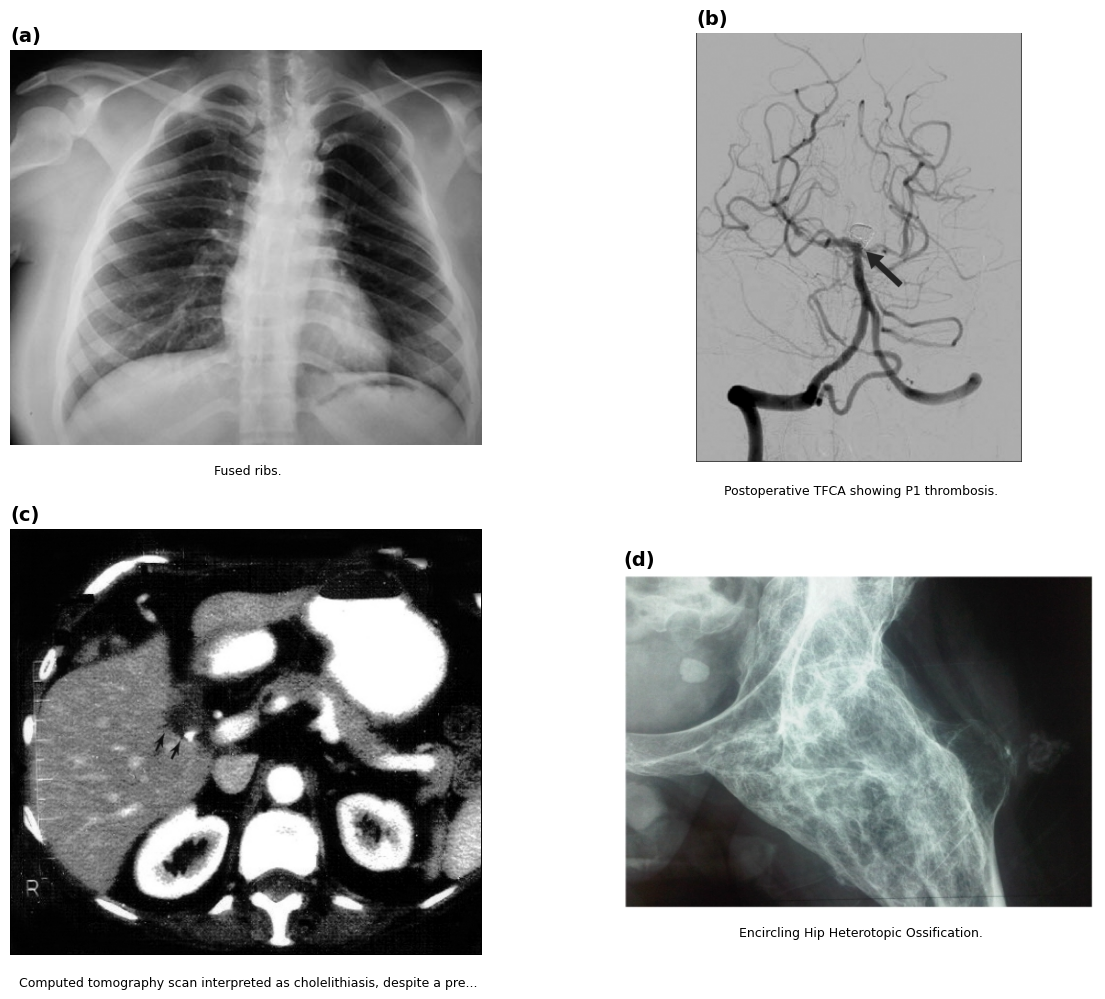

In [14]:
sample_df = train_df.sample(4, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

labels = ['(a)', '(b)', '(c)', '(d)']

for i, (_, row) in enumerate(sample_df.iterrows()):

    img = Image.open(row["image_path"]).convert("RGB")

    axes[i].imshow(img)

    # Label
    axes[i].set_title(
        labels[i],
        fontsize=14,
        fontweight='bold',
        loc='left'
    )

    # Short caption below image
    caption = row["caption"]
    if len(caption) > 70:
        caption = caption[:70] + "..."

    axes[i].text(
        0.5, -0.05,
        caption,
        ha='center',
        va='top',
        fontsize=9,
        wrap=True,
        transform=axes[i].transAxes
    )

    axes[i].axis("off")

# Increase vertical spacing
plt.subplots_adjust(hspace=0.15, wspace=0.3)

plt.show()

Average Width : 604.408
Average Height: 558.208


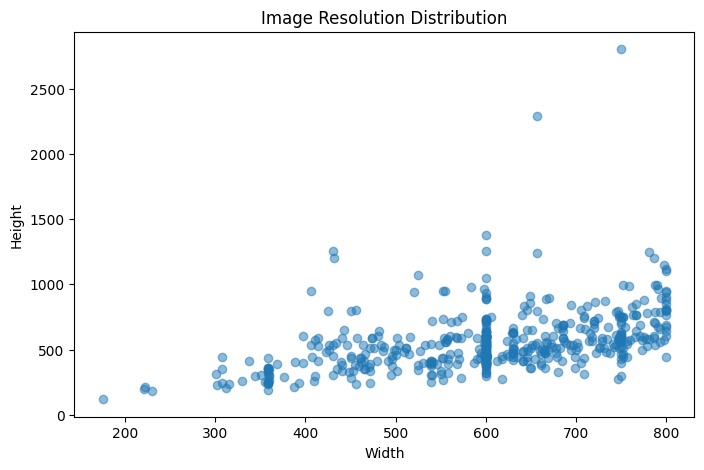

In [15]:
# ==========================================
# IMAGE RESOLUTION ANALYSIS
# ==========================================

sample_images = train_df.sample(500, random_state=42)

widths = []
heights = []

for path in sample_images["image_path"]:

    img = Image.open(path)

    widths.append(img.size[0])
    heights.append(img.size[1])

print("Average Width :", np.mean(widths))
print("Average Height:", np.mean(heights))

plt.figure(figsize=(8,5))

plt.scatter(widths, heights, alpha=0.5)

plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

In [16]:
print(train_df.columns)

Index(['id', 'name', 'caption', 'image_path'], dtype='object')


In [17]:
train_df.shape

(65419, 4)

count    65419.000000
mean        20.216848
std         16.022259
min          0.000000
25%         10.000000
50%         16.000000
75%         25.000000
max        410.000000
Name: caption_length, dtype: float64


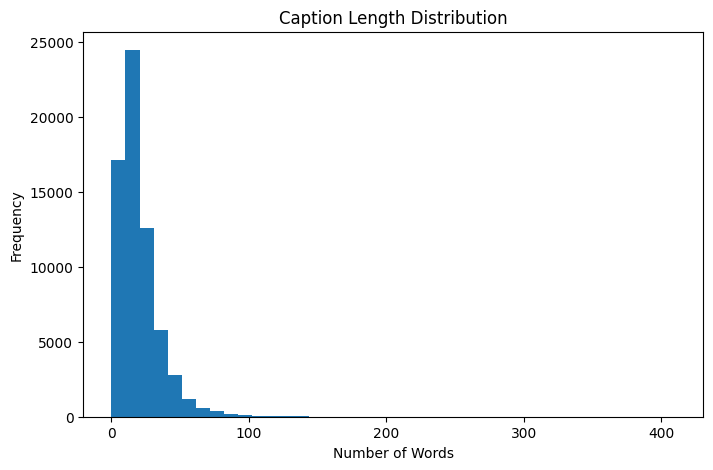

In [18]:
# ==========================================
# CAPTION LENGTH ANALYSIS
# ==========================================

train_df["caption_length"] = train_df["caption"].apply(
    lambda x: len(str(x).split())
)

print(train_df["caption_length"].describe())

plt.figure(figsize=(8,5))

plt.hist(
    train_df["caption_length"],
    bins=40
)

plt.title("Caption Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [19]:
# ==========================================
# REMOVE EMPTY CAPTIONS
# ==========================================

train_df["caption"] = train_df["caption"].fillna("").astype(str)
val_df["caption"] = val_df["caption"].fillna("").astype(str)
test_df["caption"] = test_df["caption"].fillna("").astype(str)

train_df = train_df[
    train_df["caption"].str.strip() != ""
].reset_index(drop=True)

val_df = val_df[
    val_df["caption"].str.strip() != ""
].reset_index(drop=True)

test_df = test_df[
    test_df["caption"].str.strip() != ""
].reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 65418
Validation: 8175
Test: 8176


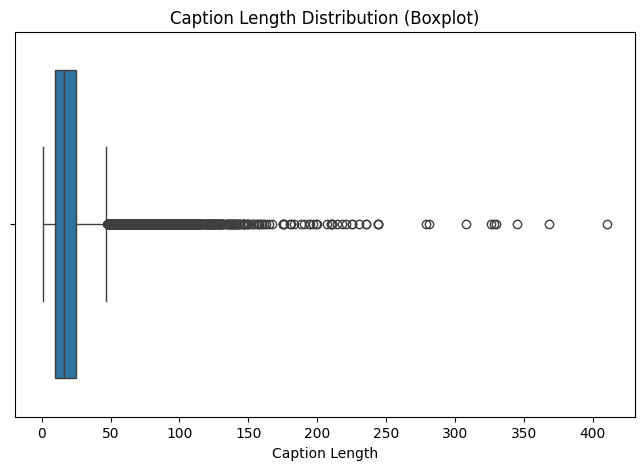

In [20]:
# ==========================================
# CAPTION LENGTH BOXPLOT
# ==========================================

train_df["caption_length"] = train_df["caption"].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(8,5))

sns.boxplot(
    x=train_df["caption_length"]
)

plt.title("Caption Length Distribution (Boxplot)")
plt.xlabel("Caption Length")

plt.show()

In [21]:
# ==========================================
# VOCABULARY ANALYSIS
# ==========================================

all_words = []

for caption in train_df["caption"]:

    words = str(caption).lower().split()

    all_words.extend(words)

word_counts = Counter(all_words)

print("Total Words:", len(all_words))
print("Unique Vocabulary:", len(word_counts))

Total Words: 1322566
Unique Vocabulary: 66517


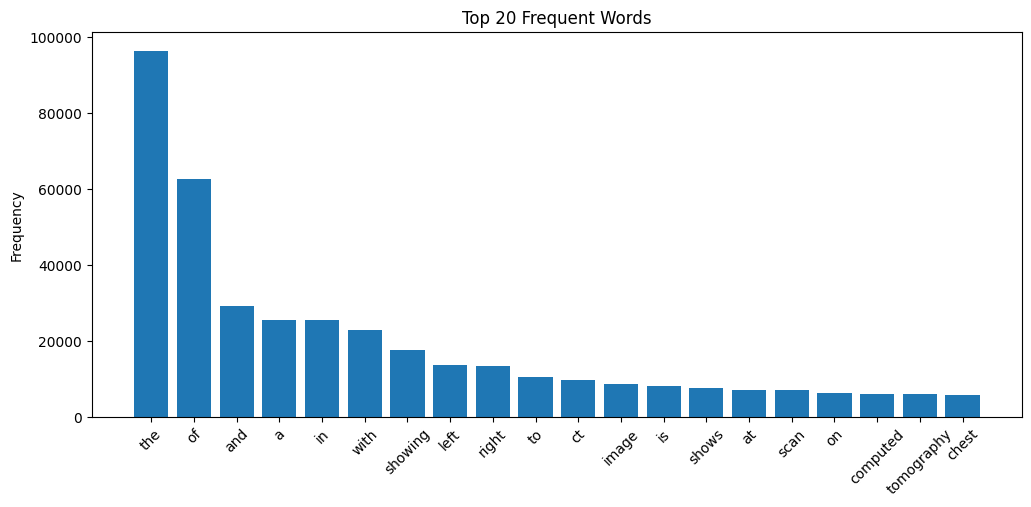

In [22]:
# ==========================================
# TOP 20 WORDS
# ==========================================

top_words = word_counts.most_common(20)

words = [x[0] for x in top_words]
freqs = [x[1] for x in top_words]

plt.figure(figsize=(12,5))

plt.bar(words, freqs)

plt.xticks(rotation=45)

plt.title("Top 20 Frequent Words")
plt.ylabel("Frequency")

plt.show()

In [23]:
# ==========================================
# CLEAN MEDICAL CAPTIONS
# ==========================================

def clean_caption(text):

    text = str(text).lower()

    # remove line breaks
    text = text.replace("\n", " ")

    # remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    # keep letters + numbers
    text = re.sub(r"[^a-z0-9\s]", "", text)

    return text.strip()


train_df["clean_caption"] = train_df["caption"].apply(clean_caption)
val_df["clean_caption"] = val_df["caption"].apply(clean_caption)
test_df["clean_caption"] = test_df["caption"].apply(clean_caption)

print(train_df[["caption","clean_caption"]].head())

                                             caption  \
0   Computed tomography scan in axial view showin...   
1   Bacterial contamination occurred after comple...   
2   The patient had residual paralysis of the han...   
3    Panoramic radiograph after immediate loading.\n   
4   Plain abdomen x-ray: Multiple air levels at t...   

                                       clean_caption  
0  computed tomography scan in axial view showing...  
1  bacterial contamination occurred after complet...  
2  the patient had residual paralysis of the hand...  
3       panoramic radiograph after immediate loading  
4  plain abdomen xray multiple air levels at the ...  


In [24]:
# ==========================================
# VOCABULARY AFTER CLEANING
# ==========================================

all_words_clean = []

for caption in train_df["clean_caption"]:

    all_words_clean.extend(caption.split())

clean_vocab = Counter(all_words_clean)

print("Total Clean Words :", len(all_words_clean))
print("Unique Clean Vocabulary :", len(clean_vocab))

Total Clean Words : 1316472
Unique Clean Vocabulary : 40948


Rare Words Removed : 20339
Words Retained : 20609


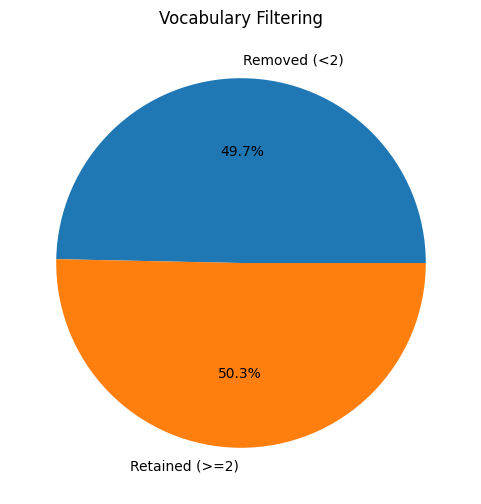

In [26]:
# ==========================================
# RARE WORD ANALYSIS
# ==========================================

rare_words = []
frequent_words = []

for word, count in clean_vocab.items():

    if count < 2:
        rare_words.append(word)
    else:
        frequent_words.append(word)

print("Rare Words Removed :", len(rare_words))
print("Words Retained :", len(frequent_words))

plt.figure(figsize=(6,6))

plt.pie(
    [len(rare_words), len(frequent_words)],
    labels=["Removed (<2)", "Retained (>=2)"],
    autopct="%1.1f%%"
)

plt.title("Vocabulary Filtering")

plt.show()

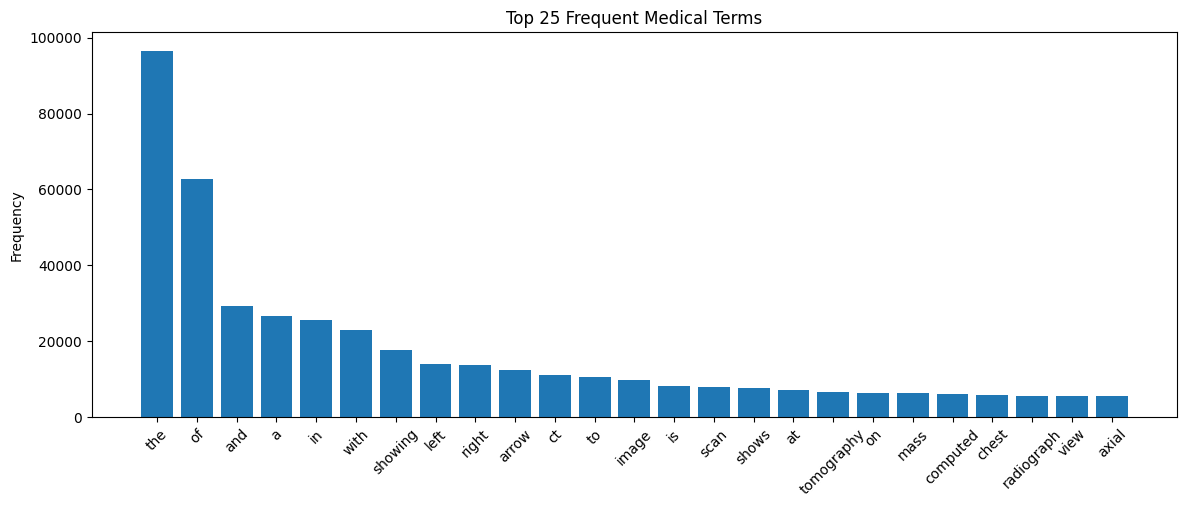

In [27]:
# ==========================================
# TOP WORDS AFTER CLEANING
# ==========================================

top_words = clean_vocab.most_common(25)

words = [x[0] for x in top_words]
freqs = [x[1] for x in top_words]

plt.figure(figsize=(14,5))

plt.bar(words, freqs)

plt.xticks(rotation=45)

plt.title("Top 25 Frequent Medical Terms")

plt.ylabel("Frequency")

plt.show()

count    65418.000000
mean        20.124003
std         15.917600
min          1.000000
25%         10.000000
50%         16.000000
75%         25.000000
max        410.000000
Name: clean_length, dtype: float64


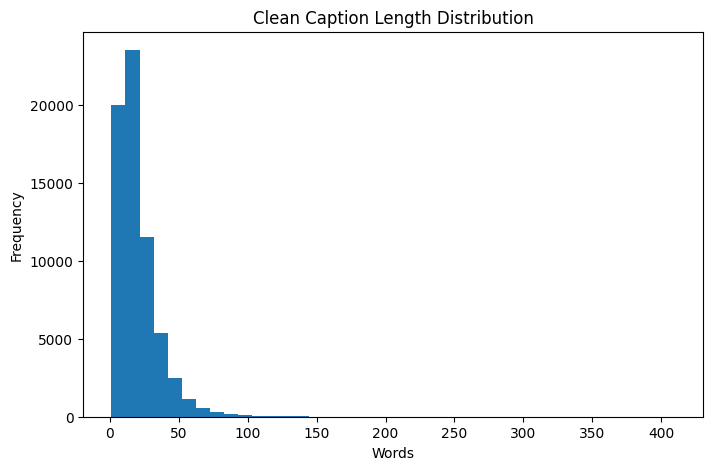

In [28]:
# ==========================================
# CLEAN CAPTION LENGTH
# ==========================================

train_df["clean_length"] = train_df["clean_caption"].apply(
    lambda x: len(x.split())
)

print(train_df["clean_length"].describe())

plt.figure(figsize=(8,5))

plt.hist(
    train_df["clean_length"],
    bins=40
)

plt.title("Clean Caption Length Distribution")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

In [29]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

Device : cpu


In [30]:
# ==========================================================
# CREATE VOCABULARY
# ==========================================================

from collections import Counter

counter = Counter()

for caption in train_df["caption"]:

    words = caption.lower().split()

    counter.update(words)

# Keep words appearing at least 1 times
min_freq = 2

vocab = [

    word

    for word, freq in counter.items()

    if freq >= min_freq

]

# Special Tokens
vocab = [

    "<PAD>",

    "<SOS>",

    "<EOS>",

    "<UNK>"

] + sorted(vocab)

word2idx = {

    word: idx

    for idx, word in enumerate(vocab)

}

idx2word = {

    idx: word

    for word, idx in word2idx.items()

}

print("="*60)

print("Vocabulary Size :", len(vocab))

print("="*60)

Vocabulary Size : 29547


In [31]:
# ==========================================================
# ENCODE CAPTIONS
# ==========================================================

MAX_LEN = 64

def encode_caption(caption):

    words = caption.lower().split()

    encoded = [

        word2idx["<SOS>"]

    ]

    for word in words:

        encoded.append(

            word2idx.get(

                word,

                word2idx["<UNK>"]

            )

        )

    encoded.append(

        word2idx["<EOS>"]

    )

    if len(encoded) < MAX_LEN:

        encoded.extend(

            [

                word2idx["<PAD>"]

            ] *

            (MAX_LEN - len(encoded))

        )

    else:

        encoded = encoded[:MAX_LEN]

    return torch.tensor(encoded)

In [32]:
# ==========================================================
# IMAGE TRANSFORMS
# ==========================================================

from torchvision import transforms

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

print("Transforms Created Successfully")

Transforms Created Successfully


In [33]:
# ==========================================================
# CUSTOM DATASET
# ==========================================================

from torch.utils.data import Dataset
from PIL import Image

class ROCODataset(Dataset):

    def __init__(

        self,

        dataframe,

        transform=None

    ):

        self.dataframe = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        image_path = self.dataframe.iloc[idx]["image_path"]

        caption = self.dataframe.iloc[idx]["caption"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:

            image = self.transform(image)

        caption = encode_caption(caption)

        return image, caption

In [39]:
# ==========================================
# DEVELOPMENT SUBSET
# ==========================================

train_subset = train_df.sample(n=5000, random_state=42)
val_subset   = val_df.sample(n=1000, random_state=42)
test_subset  = test_df.sample(n=1000, random_state=42)

print("Train:", train_subset.shape)
print("Validation:", val_subset.shape)
print("Test:", test_subset.shape)

Train: (5000, 7)
Validation: (1000, 5)
Test: (1000, 5)


In [40]:
# ==========================================================
# CREATE DATASETS
# ==========================================================

train_dataset = ROCODataset(
    train_subset,
    transform
)

val_dataset = ROCODataset(
    val_subset,
    transform
)

test_dataset = ROCODataset(
    test_subset,
    transform
)

print("=" * 60)
print("Train Samples :", len(train_dataset))
print("Validation Samples :", len(val_dataset))
print("Test Samples :", len(test_dataset))
print("=" * 60)

Train Samples : 5000
Validation Samples : 1000
Test Samples : 1000


In [41]:
# ==========================================================
# VERIFY DATASET
# ==========================================================

image, caption = train_dataset[0]

print("Image Shape :", image.shape)

print("Caption Shape :", caption.shape)

print()

print(caption[:20])

Image Shape : torch.Size([3, 224, 224])
Caption Shape : torch.Size([64])

tensor([    1, 12459, 23492,     2,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])


In [42]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders Created Successfully")

DataLoaders Created Successfully


In [43]:
# ==========================================================
# ENCODER 
# ==========================================================

import torch
import torch.nn as nn
import torchvision.models as models

class EncoderCNN(nn.Module):

    def __init__(self):

        super().__init__()

        resnet = models.resnet101(
            weights=models.ResNet101_Weights.DEFAULT
        )

        # Remove Average Pooling and FC Layer
        self.resnet = nn.Sequential(
            *list(resnet.children())[:-2]
        )

    def forward(self, images):

        features = self.resnet(images)

        # (B,2048,7,7) → (B,49,2048)
        features = features.permute(
            0, 2, 3, 1
        )

        features = features.view(
            features.size(0),
            -1,
            2048
        )

        return features

In [44]:
# ==========================================================
# ATTENTION
# ==========================================================

class Attention(nn.Module):

    def __init__(
        self,
        encoder_dim,
        decoder_dim,
        attention_dim
    ):

        super().__init__()

        self.encoder_att = nn.Linear(
            encoder_dim,
            attention_dim
        )

        self.decoder_att = nn.Linear(
            decoder_dim,
            attention_dim
        )

        self.full_att = nn.Linear(
            attention_dim,
            1
        )

        self.relu = nn.ReLU()

        self.softmax = nn.Softmax(dim=1)

    def forward(
        self,
        encoder_out,
        decoder_hidden
    ):

        att1 = self.encoder_att(
            encoder_out
        )

        att2 = self.decoder_att(
            decoder_hidden
        ).unsqueeze(1)

        att = self.full_att(

            self.relu(
                att1 + att2
            )

        ).squeeze(2)

        alpha = self.softmax(att)

        attention_weighted_encoding = (

            encoder_out *
            alpha.unsqueeze(2)

        ).sum(dim=1)

        return (

            attention_weighted_encoding,

            alpha

        )

In [45]:
# ==========================================================
# DECODER WITH ATTENTION 
# ==========================================================

import torch
import torch.nn as nn

class DecoderRNN(nn.Module):

    def __init__(
        self,
        embed_size,
        hidden_size,
        vocab_size,
        encoder_dim=2048,
        attention_dim=512,
        dropout=0.3
    ):

        super().__init__()

        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(
            vocab_size,
            embed_size
        )

        self.attention = Attention(
            encoder_dim,
            hidden_size,
            attention_dim
        )

        self.lstm = nn.LSTMCell(
            embed_size + encoder_dim,
            hidden_size
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_size,
            vocab_size
        )

    # -------------------------------------------------------
    # TRAINING
    # -------------------------------------------------------

    def forward(
        self,
        encoder_out,
        captions
    ):

        batch_size = encoder_out.size(0)

        seq_length = captions.size(1)

        embeddings = self.embedding(captions)

        h = torch.zeros(
            batch_size,
            self.hidden_size,
            device=captions.device
        )

        c = torch.zeros_like(h)

        outputs = torch.zeros(
            batch_size,
            seq_length,
            self.fc.out_features,
            device=captions.device
        )

        for t in range(seq_length):

            context, alpha = self.attention(
                encoder_out,
                h
            )

            lstm_input = torch.cat(
                (
                    embeddings[:, t],
                    context
                ),
                dim=1
            )

            h, c = self.lstm(
                lstm_input,
                (h, c)
            )

            outputs[:, t] = self.fc(
                self.dropout(h)
            )

        return outputs


    # -------------------------------------------------------
    # CAPTION GENERATION (INFERENCE)
    # -------------------------------------------------------

    def generate(
        self,
        encoder_out,
        word2idx,
        idx2word,
        max_length=30
    ):

        batch_size = encoder_out.size(0)

        h = torch.zeros(
            batch_size,
            self.hidden_size,
            device=encoder_out.device
        )

        c = torch.zeros_like(h)

        word = torch.tensor(
            [word2idx["<SOS>"]],
            device=encoder_out.device
        )

        generated_caption = []

        for _ in range(max_length):

            embedding = self.embedding(word)

            context, alpha = self.attention(
                encoder_out,
                h
            )

            lstm_input = torch.cat(
                (
                    embedding,
                    context
                ),
                dim=1
            )

            h, c = self.lstm(
                lstm_input,
                (h, c)
            )

            output = self.fc(h)

            predicted = output.argmax(1)

            predicted_idx = predicted.item()

            predicted_word = idx2word[predicted_idx]

            if predicted_word == "<EOS>":
                break

            generated_caption.append(
                predicted_word
            )

            word = predicted

        return " ".join(generated_caption)

In [46]:
# ==========================================================
# IMAGE CAPTIONING MODEL 
# ==========================================================

class ImageCaptioningModel(nn.Module):

    def __init__(
        self,
        embed_size,
        hidden_size,
        vocab_size
    ):

        super().__init__()

        self.encoder = EncoderCNN()

        self.decoder = DecoderRNN(
            embed_size,
            hidden_size,
            vocab_size
        )

    def forward(
        self,
        images,
        captions
    ):

        features = self.encoder(images)

        outputs = self.decoder(
            features,
            captions
        )

        return outputs


    # -------------------------------------------------------
    # Generate Caption
    # -------------------------------------------------------

    def generate_caption(
        self,
        image,
        word2idx,
        idx2word,
        max_length=30
    ):

        self.eval()

        with torch.no_grad():

            features = self.encoder(image)

            caption = self.decoder.generate(
                features,
                word2idx,
                idx2word,
                max_length
            )

        return caption

In [47]:
# ==========================================================
# HYPERPARAMETERS
# ==========================================================

BATCH_SIZE = 16

EMBED_SIZE = 256

HIDDEN_SIZE = 512

LEARNING_RATE = 1e-4

NUM_EPOCHS = 30

print("Hyperparameters Initialized Successfully")

Hyperparameters Initialized Successfully


In [48]:
VOCAB_SIZE = len(vocab)

model = ImageCaptioningModel(

    embed_size=EMBED_SIZE,

    hidden_size=HIDDEN_SIZE,

    vocab_size=VOCAB_SIZE

).to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:00<00:00, 221MB/s] 


ImageCaptioningModel(
  (encoder): EncoderCNN(
    (resnet): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=T

In [49]:
# ==========================================================
# LOSS FUNCTION & OPTIMIZER
# ==========================================================

criterion = nn.CrossEntropyLoss(

    ignore_index=word2idx["<PAD>"]

)

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=LEARNING_RATE

)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2

)

print("Loss Function and Optimizer Ready")

Loss Function and Optimizer Ready


In [50]:
# ==========================================================
# LEARNING RATE SCHEDULER
# ==========================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2,

    min_lr=1e-6

)

print("Learning Rate Scheduler Created Successfully")

Learning Rate Scheduler Created Successfully


In [51]:
# ==========================================================
# VERIFY DATALOADER
# ==========================================================

images, captions = next(iter(train_loader))

print("Images Shape :", images.shape)

print("Captions Shape :", captions.shape)

Images Shape : torch.Size([16, 3, 224, 224])
Captions Shape : torch.Size([16, 64])


In [52]:
# ==========================================================
# VERIFY MODEL OUTPUT
# ==========================================================

images = images.to(device)

captions = captions.to(device)

outputs = model(

    images,

    captions[:, :-1]

)

print("Output Shape :", outputs.shape)

Output Shape : torch.Size([16, 63, 29547])


In [53]:
torch.cuda.empty_cache()

a = torch.randn(2, 3, device="cuda")

print(a)

tensor([[-0.6945,  1.5017, -0.8904],
        [ 0.3802, -0.1820,  1.6818]], device='cuda:0')


In [54]:
import torch
import torch.nn as nn

device = "cuda"

conv = nn.Conv2d(3, 64, kernel_size=3).to(device)

x = torch.randn(1, 3, 224, 224).to(device)

y = conv(x)

print(y.shape)

torch.Size([1, 64, 222, 222])


In [55]:
# ==========================================================
# TRAIN ONE EPOCH
# ==========================================================

from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0

    progress = tqdm(loader)

    for images, captions in progress:

        images = images.to(device)

        captions = captions.to(device)

        optimizer.zero_grad()

        outputs = model(

            images,

            captions[:, :-1]

        )

        loss = criterion(

            outputs.reshape(-1, outputs.size(-1)),

            captions[:, 1:].reshape(-1)

        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=5

        )

        optimizer.step()

        total_loss += loss.item()

        progress.set_postfix(

            loss=loss.item()

        )

    return total_loss / len(loader)

In [56]:
# ==========================================================
# VALIDATION FUNCTION
# ==========================================================

def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        progress = tqdm(loader)

        for images, captions in progress:

            images = images.to(device)

            captions = captions.to(device)

            outputs = model(
                images,
                captions[:, :-1]
            )

            loss = criterion(
                outputs.reshape(-1, outputs.size(-1)),
                captions[:, 1:].reshape(-1)
            )

            total_loss += loss.item()

            progress.set_postfix(
                loss=loss.item()
            )

    return total_loss / len(loader)

In [57]:
# ==========================================================
# COMPLETE TRAINING LOOP
# ==========================================================

best_loss = float("inf")

train_losses = []

val_losses = []

PATIENCE = 5

patience_counter = 0

for epoch in range(NUM_EPOCHS):

    print("=" * 70)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print("=" * 70)

    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device

    )

    val_loss = validate_one_epoch(

        model,

        val_loader,

        criterion,

        device

    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    print(f"\nTrain Loss      : {train_loss:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")

    # Save Best Model
    if val_loss < best_loss:

        best_loss = val_loss

        patience_counter = 0

        torch.save(

            model.state_dict(),

            "best_model_resnet101_attention.pth"

        )

        print("✅ Best Model Saved")

    else:

        patience_counter += 1

        print(

            f"Early Stopping Counter : {patience_counter}/{PATIENCE}"

        )

    # Early Stopping
    if patience_counter >= PATIENCE:

        print("\nEarly Stopping Triggered")

        break

Epoch 1/30


100%|██████████| 63/63 [00:11<00:00,  5.44it/s, loss=6.63]



Train Loss      : 7.4876
Validation Loss : 6.8525
✅ Best Model Saved
Epoch 2/30


100%|██████████| 63/63 [00:11<00:00,  5.54it/s, loss=6.22]



Train Loss      : 6.7509
Validation Loss : 6.5506
✅ Best Model Saved
Epoch 3/30


...


Train Loss      : 4.0625
Validation Loss : 5.9699
Early Stopping Counter : 3/5
Epoch 18/30


100%|██████████| 63/63 [00:11<00:00,  5.53it/s, loss=5.66]



Train Loss      : 3.8753
Validation Loss : 6.0024
Early Stopping Counter : 4/5
Epoch 19/30


100%|██████████| 63/63 [00:11<00:00,  5.51it/s, loss=5.66]


Train Loss      : 3.7268
Validation Loss : 6.0780
Early Stopping Counter : 5/5

Early Stopping Triggered


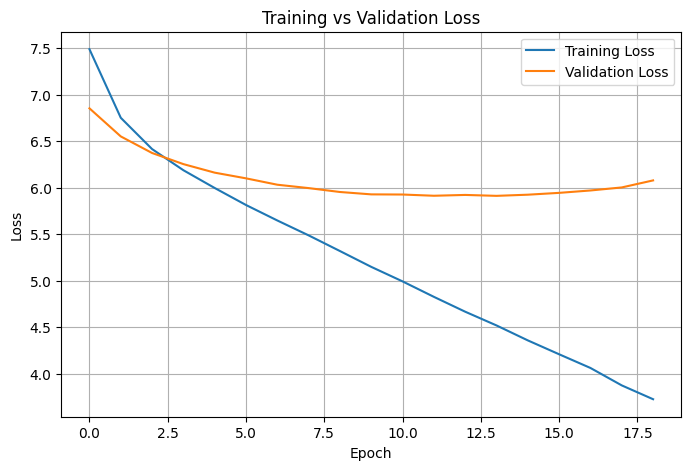

In [64]:
# ==========================================================
# PLOT TRAINING & VALIDATION LOSS
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [65]:
# ==========================================================
# CREATE MODEL
# ==========================================================

EMBED_SIZE = 256
HIDDEN_SIZE = 512
VOCAB_SIZE = len(vocab)

model = ImageCaptioningModel(
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    vocab_size=VOCAB_SIZE
).to(device)

print("=" * 60)
print("Model Created Successfully")
print("=" * 60)

Model Created Successfully


In [66]:
# ==========================================================
# LOAD BEST MODEL
# ==========================================================

checkpoint = torch.load(
    "best_model_resnet101_attention.pth",
    map_location=device
)

model.load_state_dict(checkpoint)

model.eval()

print("=" * 60)
print("Best Model Loaded Successfully")
print("=" * 60)

Best Model Loaded Successfully


In [67]:
# ==========================================================
# GENERATE CAPTION
# ==========================================================

def generate_caption(

    model,

    image,

    vocab,

    max_length=30

):

    model.eval()

    with torch.no_grad():

        image = image.unsqueeze(0).to(device)

        features = model.encoder(image)

        states = None

        words = ["<SOS>"]

        for _ in range(max_length):

            caption = torch.tensor(

                [[vocab.stoi[word] for word in words]],

                device=device

            )

            outputs = model.decoder(

                features,

                caption

            )

            predicted = outputs[:, -1, :].argmax(1).item()

            word = vocab.itos[predicted]

            if word == "<EOS>":

                break

            words.append(word)

        return " ".join(words[1:])

In [68]:
print(type(vocab))

print(vocab[:10])

print(type(train_dataset))

<class 'list'>
['<PAD>', '<SOS>', '<EOS>', '<UNK>', '"', '"1"', '"5".', '"a"', '"a".', '"b"']
<class '__main__.ROCODataset'>


In [69]:
# ==========================================================
# TEST ON ONE IMAGE
# ==========================================================

image, caption = test_dataset[0]

image = image.unsqueeze(0).to(device)

predicted_caption = model.generate_caption(
    image,
    word2idx,
    idx2word,
    max_length=30
)

print("=" * 60)

print("Predicted Caption:")
print(predicted_caption)

print("=" * 60)

Predicted Caption:
postoperative radiograph of the femoral hip after the femoral bone


In [70]:
import torch
import pandas as pd
import numpy as np

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

In [75]:
print(list(word2idx.keys())[:20])

['<PAD>', '<SOS>', '<EOS>', '<UNK>', '"', '"1"', '"5".', '"a"', '"a".', '"b"', '"b".', '"crazy-paving"', '"e"', '"en', '"grade', '"home', '"target', '"tram', '"u"', '"z"']


In [76]:
from PIL import Image
import torch

def generate_caption(image, max_len=20, beam_width=3):

    model.eval()

    with torch.no_grad():

        # ==========================================
        # Convert PIL Image to Tensor 
        # ==========================================
        if isinstance(image, Image.Image):
            image = transform(image)

        # Add batch dimension if missing
        if image.dim() == 3:
            image = image.unsqueeze(0)

        image = image.to(device)

        # ==========================================
        # Extract Image Features
        # ==========================================
        features = model.encoder(image)

        start_token = word2idx["<SOS>"]
        end_token = word2idx["<EOS>"]

        beams = [
            ([start_token], 0.0)
        ]

        for _ in range(max_len):

            candidates = []

            for seq, score in beams:

                if seq[-1] == end_token:
                    candidates.append((seq, score))
                    continue

                caption_input = torch.tensor(
                    [seq],
                    dtype=torch.long
                ).to(device)

                outputs = model.decoder(
                    features,
                    caption_input
                )

                probs = torch.softmax(
                    outputs[:, -1, :],
                    dim=-1
                )

                top_probs, top_ids = torch.topk(
                    probs,
                    beam_width
                )

                for i in range(beam_width):

                    next_seq = seq + [
                        top_ids[0, i].item()
                    ]

                    next_score = (
                        score +
                        torch.log(top_probs[0, i]).item()
                    )

                    candidates.append(
                        (next_seq, next_score)
                    )

            beams = sorted(
                candidates,
                key=lambda x: x[1],
                reverse=True
            )[:beam_width]

        best_sequence = beams[0][0]

        caption = []

        for token in best_sequence:

            if token == start_token:
                continue

            if token == end_token:
                break

            caption.append(idx2word[token])

    return " ".join(caption)

In [77]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
import pandas as pd
import numpy as np

smooth = SmoothingFunction().method1
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

results = []

for i in range(len(test_dataset)):

    image, _ = test_dataset[i]

    true_caption = str(
    test_dataset.dataframe.iloc[i]["caption"]
).strip()

    predicted_caption = generate_caption(
        image=image,
        beam_width=3
    ).strip()

    reference = [true_caption.split()]
    candidate = predicted_caption.split()

    bleu1 = sentence_bleu(
        reference,
        candidate,
        weights=(1,0,0,0),
        smoothing_function=smooth
    )

    bleu2 = sentence_bleu(
        reference,
        candidate,
        weights=(0.5,0.5,0,0),
        smoothing_function=smooth
    )

    bleu3 = sentence_bleu(
        reference,
        candidate,
        weights=(1/3,1/3,1/3,0),
        smoothing_function=smooth
    )

    bleu4 = sentence_bleu(
        reference,
        candidate,
        weights=(0.25,0.25,0.25,0.25),
        smoothing_function=smooth
    )

    rouge_l = rouge.score(
        true_caption,
        predicted_caption
    )["rougeL"].fmeasure

    meteor = meteor_score(
        [true_caption.split()],
        candidate
    )

    results.append({
        "True Caption": true_caption,
        "Predicted Caption": predicted_caption,
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-3": bleu3,
        "BLEU-4": bleu4,
        "ROUGE-L": rouge_l,
        "METEOR": meteor
    })

result_df = pd.DataFrame(results)

In [78]:
print("\n===== Average Scores on Test Set =====")

print(f"BLEU-1  : {result_df['BLEU-1'].mean():.4f}")
print(f"BLEU-2  : {result_df['BLEU-2'].mean():.4f}")
print(f"BLEU-3  : {result_df['BLEU-3'].mean():.4f}")
print(f"BLEU-4  : {result_df['BLEU-4'].mean():.4f}")
print(f"ROUGE-L : {result_df['ROUGE-L'].mean():.4f}")
print(f"METEOR  : {result_df['METEOR'].mean():.4f}")


===== Average Scores on Test Set =====
BLEU-1  : 0.1167
BLEU-2  : 0.0593
BLEU-3  : 0.0310
BLEU-4  : 0.0200
ROUGE-L : 0.1838
METEOR  : 0.1290
